In [ ]:
# Install required libraries
!pip install gensim numpy matplotlib scikit-learn

# Import libraries
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
# Load pre-trained word vectors
print("Loading pre-trained word vectors...")
word_vectors = api.load("word2vec-google-news-300")


# Function to perform vector arithmetic and find similar words
def explore_word_relationships(word1, word2, word3):
    try:
        # Perform vector arithmetic: word1 - word2 + word3
        result_vector = word_vectors[word1] - word_vectors[word2] + word_vectors[word3]

        # Find similar words
        similar_words = word_vectors.similar_by_vector(result_vector, topn=10)

        # Exclude input words
        input_words = {word1, word2, word3}
        filtered_words = [
            (word, similarity)
            for word, similarity in similar_words
            if word not in input_words
        ]

        print(f"\nWord Relationship: {word1} - {word2} + {word3}")
        print("Most similar words (excluding input words):")

        for word, similarity in filtered_words[:5]:
            print(f"{word}: {similarity:.4f}")

        return filtered_words

    except KeyError as e:
        print(f"Error: {e} not found in the vocabulary.")
        return []

Loading pre-trained word vectors...


In [ ]:
# Function to visualize word embeddings
def visualize_word_embeddings(words, vectors, method='pca'):

    # Choose dimensionality reduction method
    if method == 'pca':
        reducer = PCA(n_components=2)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, random_state=42, perplexity=3)
    else:
        raise ValueError("Method must be 'pca' or 'tsne'.")

    # Reduce dimensions
    reduced_vectors = reducer.fit_transform(vectors)

    # Plot
    plt.figure(figsize=(10, 8))

    for i, word in enumerate(words):
        plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1])
        plt.text(
            reduced_vectors[i, 0] + 0.02,
            reduced_vectors[i, 1] + 0.02,
            word,
            fontsize=12
        )

    plt.title(f"Word Embeddings Visualization using {method.upper()}")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True)
    plt.show()

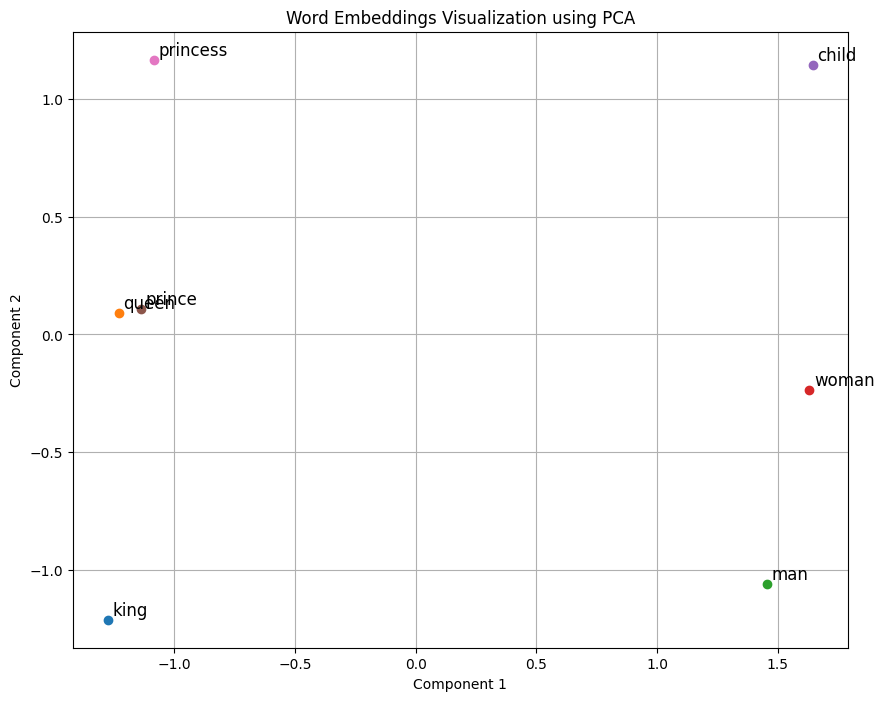

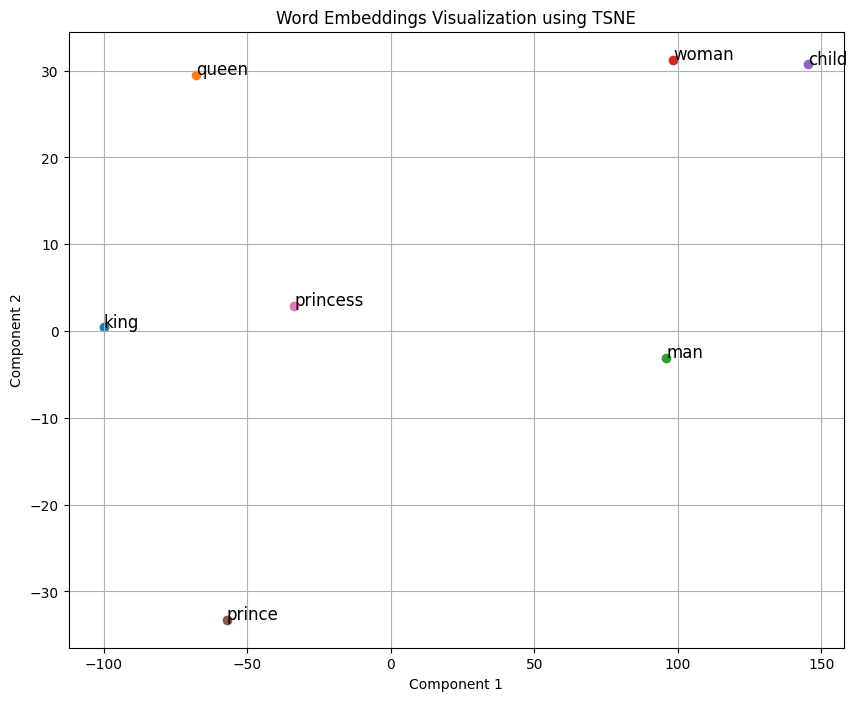

In [ ]:
# Words to visualize
words = ["king", "queen", "man", "woman", "child", "prince", "princess"]

vectors = []
valid_words = []

# Extract vectors safely
for word in words:
    if word in word_vectors:
        vectors.append(word_vectors[word])
        valid_words.append(word)
    else:
        print(f"{word} not found in vocabulary")

# Convert to numpy array
vectors = np.array(vectors)

# Plot PCA graph
visualize_word_embeddings(valid_words, vectors, method='pca')

# Plot t-SNE graph
visualize_word_embeddings(valid_words, vectors, method='tsne')

In [ ]:
explore_word_relationships("king", "man", "woman")


Word Relationship: king - man + woman
Most similar words (excluding input words):
queen: 0.7301
monarch: 0.6455
princess: 0.6156
crown_prince: 0.5819
prince: 0.5777


[('queen', 0.7300517559051514),
 ('monarch', 0.645466148853302),
 ('princess', 0.6156251430511475),
 ('crown_prince', 0.5818676352500916),
 ('prince', 0.5777117609977722),
 ('kings', 0.5613663792610168),
 ('sultan', 0.5376775860786438),
 ('Queen_Consort', 0.5344247817993164),
 ('queens', 0.5289887189865112)]